In [2]:
import pandas as pd
from pathlib import Path
from PIL import Image

# ── Configuration ─────────────────────────────────────────────────────────────
# Point this to your RAW data folders
DATASETS = {
    "Machine_S": Path(r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\raw_data\Machine_S"),
    "Machine_DSV": Path(r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\raw_data\Machine_DSV")
}

IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

# ──────────────────────────────────────────────────────────────────────────────
def extract_image_properties(img_path: Path, dataset_name: str) -> dict:
    """Reads the header of an image and extracts size, mode, and physical metadata."""
    try:
        # Image.open reads the header only, it is extremely fast
        with Image.open(img_path) as img:
            
            # 1. Check basic size and channel mode
            # 'L' = 8-bit grayscale, 'RGB' = 3-channel, 'I;16' = 16-bit grayscale
            data = {
                "Dataset": dataset_name,
                "Filename": img_path.name,
                "Format": img.format,
                "Mode": img.mode,
                "Width": img.width,
                "Height": img.height,
            }
            
            # 2. Look for DPI / physical pixel spacing in metadata
            dpi = img.info.get("dpi")
            if dpi and len(dpi) >= 2:
                data["DPI_X"] = round(dpi[0], 2)
                data["DPI_Y"] = round(dpi[1], 2)
                # Convert DPI (dots per inch) to mm per pixel (1 inch = 25.4 mm)
                data["Pixel_Spacing_X (mm)"] = round(25.4 / dpi[0], 4)
                data["Pixel_Spacing_Y (mm)"] = round(25.4 / dpi[1], 4)
            else:
                data["DPI_X"] = None
                data["DPI_Y"] = None
                data["Pixel_Spacing_X (mm)"] = None
                data["Pixel_Spacing_Y (mm)"] = None
                
            # 3. Capture what metadata keys actually exist in the file
            data["Available_Metadata"] = ", ".join(list(img.info.keys()))
            
            return data
            
    except Exception as e:
        return {"Dataset": dataset_name, "Filename": img_path.name, "Error": str(e)}


def run_sanity_check():
    results = []
    
    for dataset_name, root_path in DATASETS.items():
        print(f"Scanning {dataset_name}...")
        if not root_path.exists():
            print(f"  ⚠ Path not found: {root_path}")
            continue
            
        # Grab a sample or all images (we will scan all since header reading is fast)
        image_paths = [p for p in root_path.rglob("*") if p.suffix.lower() in IMG_EXTS]
        print(f"  Found {len(image_paths)} images. Extracting metadata...")
        
        for p in image_paths:
            stats = extract_image_properties(p, dataset_name)
            results.append(stats)
            
    # Create a DataFrame for easy analysis
    df = pd.DataFrame(results)
    
    print("\n" + "═"*60)
    print(" SANITY CHECK SUMMARY")
    print("═"*60)
    
    # Check 1: Do the image dimensions match?
    print("\n--- Image Sizes (Width x Height) ---")
    print(df.groupby(['Dataset', 'Width', 'Height']).size().to_string())

    # Check 2: Are the color modes/bit-depths the same?
    print("\n--- Image Modality (Bit-Depth & Channels) ---")
    print("Modes meaning: 'L' = 8-bit Gray, 'RGB' = Color, 'I;16' = 16-bit Gray")
    print(df.groupby(['Dataset', 'Mode']).size().to_string())

    # Check 3: Do we have pixel spacing metadata?
    print("\n--- Pixel Spacing (mm/pixel) ---")
    if df['Pixel_Spacing_X (mm)'].isnull().all():
        print("⚠ NO pixel spacing or DPI metadata found in ANY images.")
    else:
        print(df.groupby(['Dataset', 'Pixel_Spacing_X (mm)']).size().to_string())
        
    # Save the full report to Excel/CSV so you can look at individual anomalies
    df.to_xls("dataset_sanity_report.xls", index=False)
    print("\n✅ Full detailed report saved to 'dataset_sanity_report.xls'")

if __name__ == "__main__":
    run_sanity_check()

Scanning Machine_S...
  Found 866 images. Extracting metadata...
Scanning Machine_DSV...
  Found 1727 images. Extracting metadata...

════════════════════════════════════════════════════════════
 SANITY CHECK SUMMARY
════════════════════════════════════════════════════════════

--- Image Sizes (Width x Height) ---
Dataset      Width  Height
Machine_DSV  1024   512       1727
Machine_S    1024   512        866

--- Image Modality (Bit-Depth & Channels) ---
Modes meaning: 'L' = 8-bit Gray, 'RGB' = Color, 'I;16' = 16-bit Gray
Dataset      Mode
Machine_DSV  L       1727
Machine_S    L        866

--- Pixel Spacing (mm/pixel) ---
⚠ NO pixel spacing or DPI metadata found in ANY images.


AttributeError: 'DataFrame' object has no attribute 'to_xls'

In [16]:
# scripts/check_dataset.py

from pathlib import Path
from PIL import Image
import collections, os

def check_resolutions(dataset_root: str):
    root = Path(dataset_root)
    resolution_counter = collections.Counter()
    format_counter     = collections.Counter()
    problem_files      = []

    # 1. Define allowed extensions
    allowed_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
    
    # 2. Find the images FIRST
    image_paths = [p for p in root.rglob("*") if p.suffix.lower() in allowed_exts]

    # 3. THEN print how many were found
    print(f"Total images found: {len(image_paths)}")

    for p in image_paths:
        try:
            with Image.open(p) as img:
                resolution_counter[img.size]  += 1
                format_counter[img.format]    += 1
                # Check for grayscale vs RGB
                if img.mode not in ("L", "RGB", "RGBA"):
                    problem_files.append((str(p), f"Unusual mode: {img.mode}"))
        except Exception as e:
            problem_files.append((str(p), str(e)))

    print("\n── Resolutions (W×H : count) ──")
    for res, cnt in resolution_counter.most_common():
        print(f"  {res[0]}×{res[1]:>5} : {cnt}")

    print("\n── Formats ──")
    for fmt, cnt in format_counter.most_common():
        print(f"  {fmt}: {cnt}")

    if problem_files:
        print(f"\n⚠️  {len(problem_files)} problem files:")
        for path, reason in problem_files[:20]:
            print(f"  {path}  →  {reason}")
    else:
        print("\n✅ No problem files found.")

    return resolution_counter, problem_files


# ==========================================
# APPLIED TO YOUR SPECIFIC CASE
# ==========================================

if __name__ == "__main__":
    # If you are running this locally on your Windows machine:
    machine_s_path = r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\raw_data\Machine_S"
    machine_dsv_path = r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\raw_data\Machine_DSV"
    
    # NOTE: If you run this in Google Colab instead, uncomment the two lines below:
    # machine_s_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_S"
    # machine_dsv_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_DSV"

    print("════════════════════════════════════════")
    print(" SCANNING: Machine_S")
    print("════════════════════════════════════════")
    check_resolutions(machine_s_path)

    print("\n════════════════════════════════════════")
    print(" SCANNING: Machine_DSV")
    print("════════════════════════════════════════")
    check_resolutions(machine_dsv_path)

════════════════════════════════════════
 SCANNING: Machine_S
════════════════════════════════════════
Total images found: 866

── Resolutions (W×H : count) ──
  1024×  512 : 866

── Formats ──
  TIFF: 866

✅ No problem files found.

════════════════════════════════════════
 SCANNING: Machine_DSV
════════════════════════════════════════
Total images found: 1727

── Resolutions (W×H : count) ──
  1024×  512 : 1727

── Formats ──
  TIFF: 1727

✅ No problem files found.


In [17]:
# scripts/check_corrupt_and_duplicates.py

import hashlib
import numpy as np
from pathlib import Path
from PIL import Image

# Unified set of allowed extensions based on your X-ray datasets
ALLOWED_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def find_corrupted_images(dataset_root: str):
    """Try to fully load every image; log failures or blank images."""
    bad = []
    for p in Path(dataset_root).rglob("*"):
        if p.suffix.lower() not in ALLOWED_EXTS:
            continue
        try:
            with Image.open(p) as img:
                img.load()               # force full decode
                arr = np.array(img)
                if arr.std() < 1e-3:     # nearly blank / all-black image
                    bad.append((str(p), "Near-blank image (std < 0.001)"))
        except Exception as e:
            bad.append((str(p), str(e)))
    return bad

def find_duplicates(dataset_root: str):
    """MD5-based exact duplicate detection."""
    hashes = {}
    duplicates = []
    for p in Path(dataset_root).rglob("*"):
        if p.suffix.lower() not in ALLOWED_EXTS:
            continue
        md5 = hashlib.md5(p.read_bytes()).hexdigest()
        if md5 in hashes:
            duplicates.append((str(p), hashes[md5]))
        else:
            hashes[md5] = str(p)
    return duplicates

def scan_dataset(name: str, path: str):
    """Runs both checks on a specific dataset and prints the results."""
    print(f"\n{'═'*60}")
    print(f" SCANNING: {name}")
    print(f"{'═'*60}")
    
    if not Path(path).exists():
        print(f"⚠️ Directory not found: {path}")
        return

    # 1. Corrupt / Blank Check
    print("Checking for corrupted or blank images (this may take a minute)...")
    bad_images = find_corrupted_images(path)
    print(f"  -> Corrupted / blank found: {len(bad_images)}")
    for p, reason in bad_images[:10]:
        print(f"     {Path(p).name}: {reason}")

    # 2. Duplicate Check
    print("\nChecking for exact duplicates...")
    duplicates = find_duplicates(path)
    print(f"  -> Exact duplicates found: {len(duplicates)}")
    for dup, orig in duplicates[:10]:
        print(f"     {Path(dup).name}  →  duplicate of  {Path(orig).name}")


# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    # Windows Paths:
    machine_s_path = r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\raw_data\Machine_S"
    machine_dsv_path = r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\raw_data\Machine_DSV"

    # NOTE: If running in Colab, uncomment the two lines below:
    # machine_s_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_S"
    # machine_dsv_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_DSV"

    scan_dataset("Machine_S", machine_s_path)
    scan_dataset("Machine_DSV", machine_dsv_path)


════════════════════════════════════════════════════════════
 SCANNING: Machine_S
════════════════════════════════════════════════════════════
Checking for corrupted or blank images (this may take a minute)...
  -> Corrupted / blank found: 0

Checking for exact duplicates...
  -> Exact duplicates found: 0

════════════════════════════════════════════════════════════
 SCANNING: Machine_DSV
════════════════════════════════════════════════════════════
Checking for corrupted or blank images (this may take a minute)...
  -> Corrupted / blank found: 0

Checking for exact duplicates...
  -> Exact duplicates found: 0


Generating visuals for Machine_S...


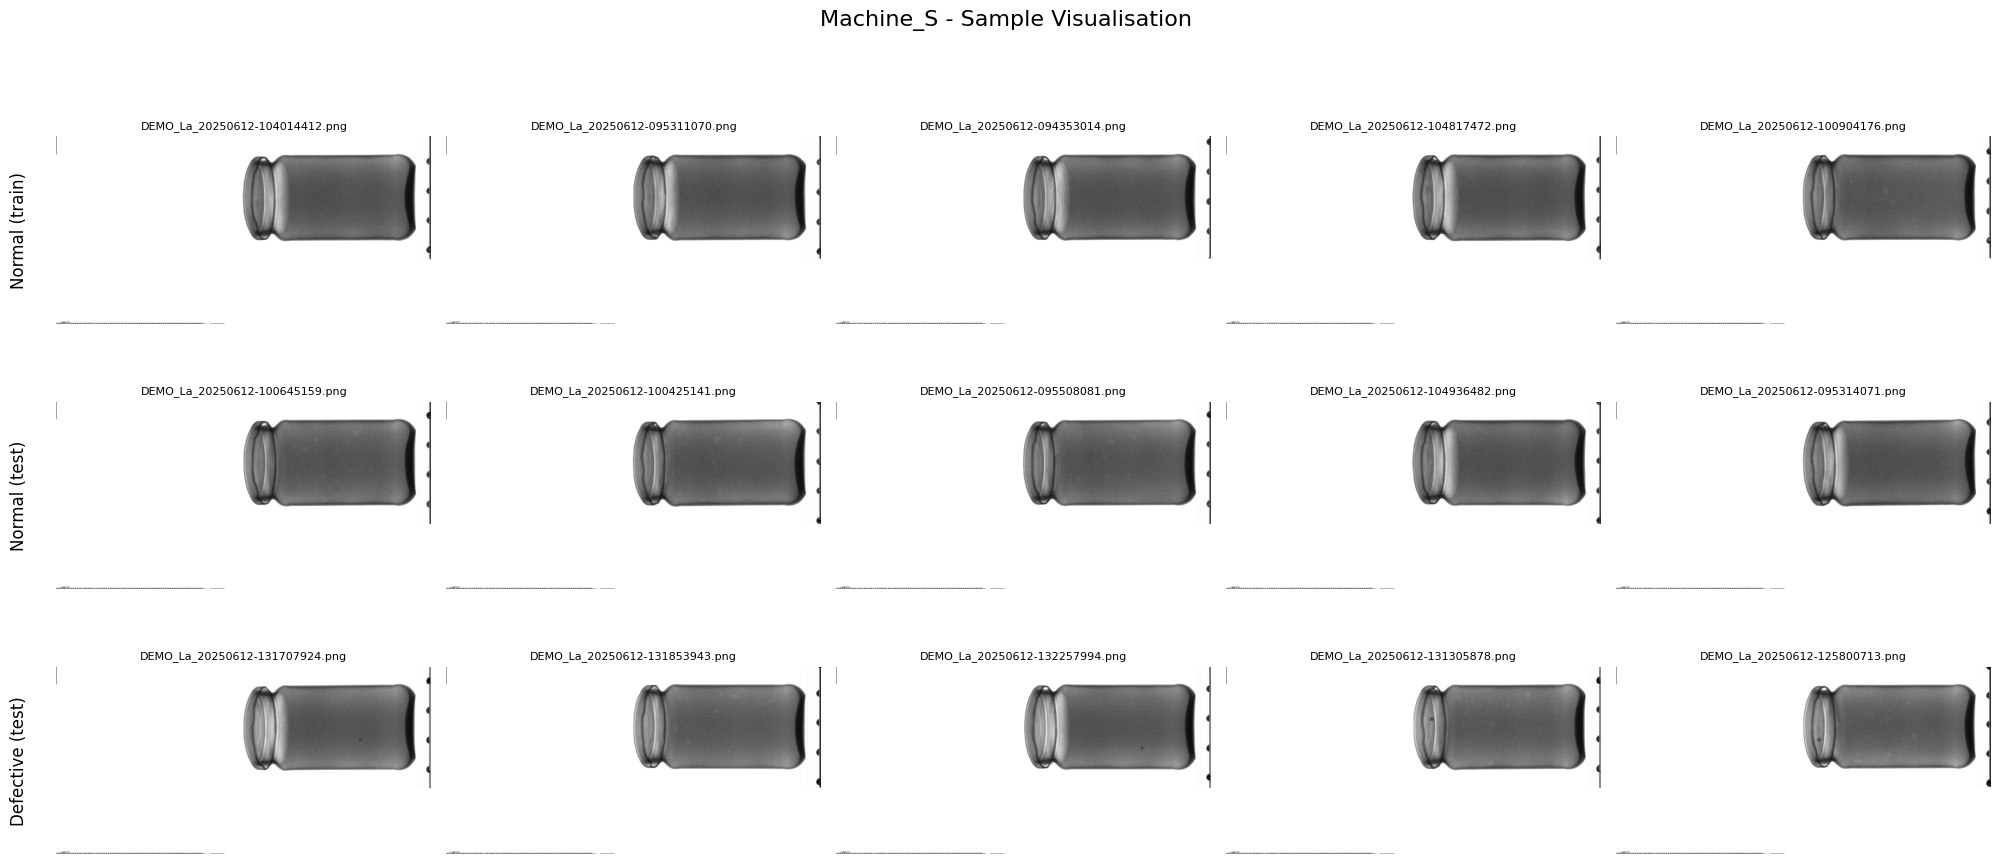

✅ Saved plot to results/Machine_S_sample_visualisation.png

Generating visuals for Machine_DSV...


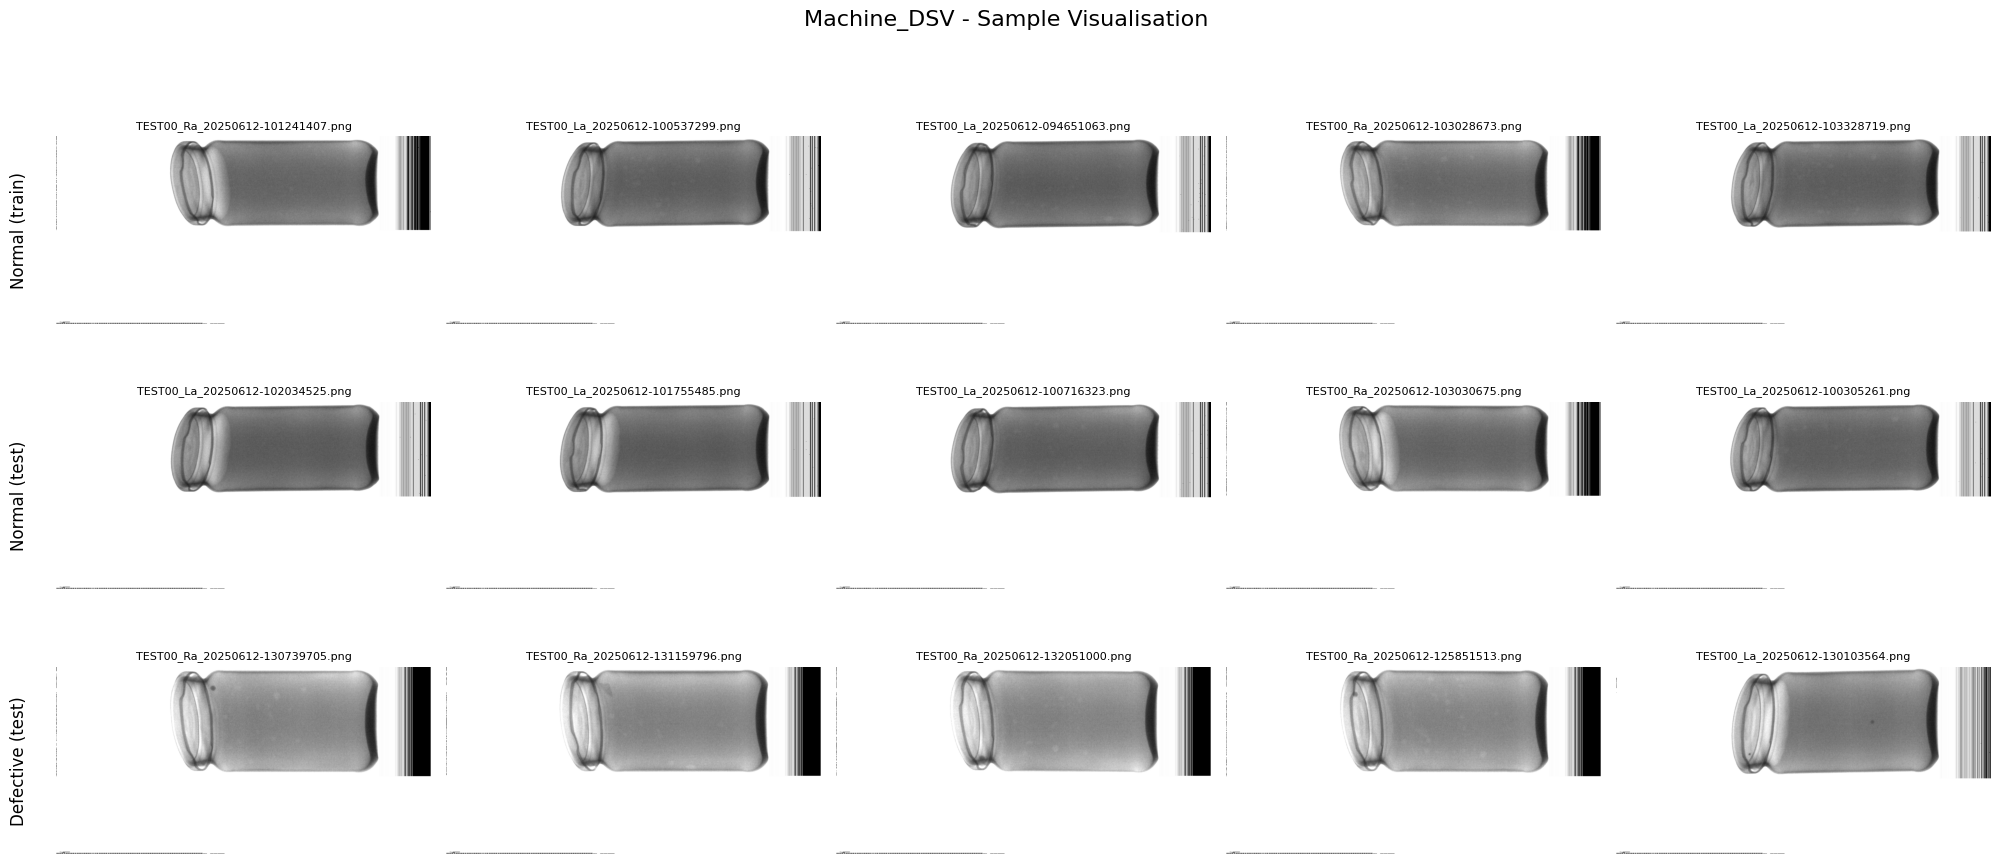

✅ Saved plot to results/Machine_DSV_sample_visualisation.png


In [18]:
# scripts/visualise_samples.py

import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Unified set of allowed extensions based on your X-ray datasets
ALLOWED_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def visualise_samples(dataset_root: str, dataset_name: str, n_per_class: int = 4, seed: int = 42):
    random.seed(seed)
    root = Path(dataset_root)
    
    # Updated to match your exact folder structure
    categories = {
        "train/good": "Normal (train)",
        "test/good":  "Normal (test)",
        "test/bad":   "Defective (test)",
    }
    
    # Ensure results directory exists
    Path("results").mkdir(exist_ok=True)

    # Set up the matplotlib figure
    fig, axes_rows = plt.subplots(
        len(categories), n_per_class,
        figsize=(4 * n_per_class, 3 * len(categories))
    )

    for row_idx, (rel_path, label) in enumerate(categories.items()):
        folder = root / rel_path
        
        # Safely collect images using our established extension list
        if folder.exists():
            imgs = sorted([p for p in folder.iterdir() if p.suffix.lower() in ALLOWED_EXTS])
        else:
            imgs = []
            print(f"⚠️ Warning: Folder not found -> {folder}")
            
        sample = random.sample(imgs, min(n_per_class, len(imgs)))

        for col_idx in range(n_per_class):
            ax = axes_rows[row_idx][col_idx]
            ax.axis("off")
            
            if col_idx < len(sample):
                # Convert to "L" (8-bit grayscale) to match your dataset modality
                img = Image.open(sample[col_idx]).convert("L")
                ax.imshow(img, cmap="gray")
                
                # Add titles and labels
                ax.set_title(sample[col_idx].name, fontsize=8)
                if col_idx == 0:
                    # Add row label on the far left
                    ax.text(-0.1, 0.5, label, fontsize=12, rotation=90, 
                            va='center', ha='center', transform=ax.transAxes)

    plt.suptitle(f"{dataset_name} - Sample Visualisation", fontsize=16, y=1.02)
    plt.tight_layout()
    
    # Save with the dataset name in the file
    save_path = f"results/{dataset_name}_sample_visualisation.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved plot to {save_path}")


# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    # Point these to your RESTRUCTURED anomalib_data folders, NOT the raw data!
    base_out_dir = r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\anomalib_data"
    
    machine_s_path = f"{base_out_dir}\\Machine_S"
    machine_dsv_path = f"{base_out_dir}\\Machine_DSV"

    # NOTE: If running in Colab, update paths:
    # machine_s_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_S"
    # machine_dsv_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_DSV"

    print("Generating visuals for Machine_S...")
    visualise_samples(machine_s_path, dataset_name="Machine_S", n_per_class=5)

    print("\nGenerating visuals for Machine_DSV...")
    visualise_samples(machine_dsv_path, dataset_name="Machine_DSV", n_per_class=5)


══════════════════════════════════════════════════
 Class Balance: Machine_S
══════════════════════════════════════════════════
  train/good            488 images
  test/good             123 images
  test/bad              255 images

  Test defect ratio: 67.5%
  ⚠️ More defects than normals — unusual for anomaly detection.


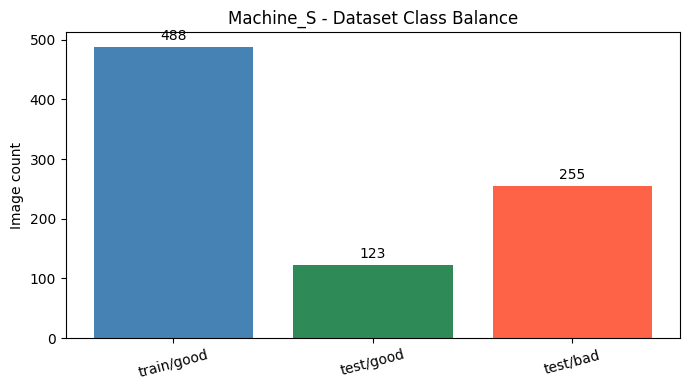

✅ Saved plot to results/Machine_S_class_balance.png

══════════════════════════════════════════════════
 Class Balance: Machine_DSV
══════════════════════════════════════════════════
  train/good            977 images
  test/good             245 images
  test/bad              505 images

  Test defect ratio: 67.3%
  ⚠️ More defects than normals — unusual for anomaly detection.


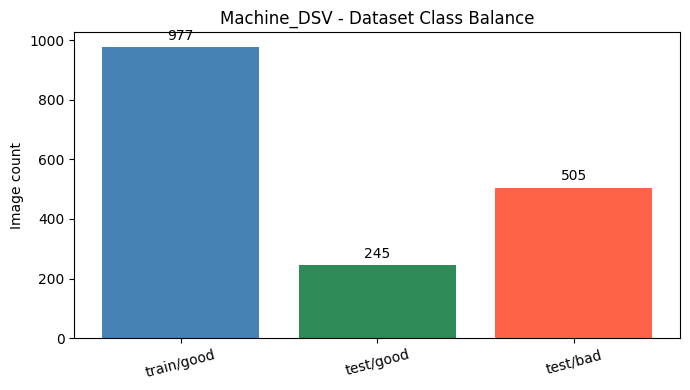

✅ Saved plot to results/Machine_DSV_class_balance.png


In [19]:
# scripts/class_balance.py

from pathlib import Path
import matplotlib.pyplot as plt

# Unified set of allowed extensions based on your X-ray datasets
ALLOWED_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def check_class_balance(dataset_root: str, dataset_name: str):
    root = Path(dataset_root)
    
    # Updated to match your exact folder structure
    categories = ["train/good", "test/good", "test/bad"]
    counts = {}

    for folder in categories:
        p = root / folder
        if p.exists():
            # Safely count images using our allowed extensions
            n = len([f for f in p.iterdir() if f.suffix.lower() in ALLOWED_EXTS])
            counts[folder] = n
        else:
            counts[folder] = 0

    total_test = counts["test/good"] + counts["test/bad"]
    defect_ratio = counts["test/bad"] / max(total_test, 1)

    print(f"\n{'═'*50}")
    print(f" Class Balance: {dataset_name}")
    print(f"{'═'*50}")
    
    for k, v in counts.items():
        print(f"  {k:<20} {v:>4} images")

    print(f"\n  Test defect ratio: {defect_ratio:.1%}")

    if defect_ratio < 0.1:
        print("  ⚠️ Highly imbalanced test set — AUROC is more reliable than accuracy.")
    elif defect_ratio > 0.6:
        print("  ⚠️ More defects than normals — unusual for anomaly detection.")
    else:
        print("  ✅ Reasonable balance.")

    # -- Bar chart --
    Path("results").mkdir(exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        list(counts.keys()), 
        list(counts.values()),
        color=["steelblue", "seagreen", "tomato"]
    )
    
    ax.bar_label(bars, padding=3)
    ax.set_ylabel("Image count")
    ax.set_title(f"{dataset_name} - Dataset Class Balance")
    
    plt.xticks(rotation=15)
    plt.tight_layout()
    
    save_path = f"results/{dataset_name}_class_balance.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✅ Saved plot to {save_path}")


# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    # Point these to your RESTRUCTURED anomalib_data folders!
    base_out_dir = r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\anomalib_data"
    
    machine_s_path = f"{base_out_dir}\\Machine_S"
    machine_dsv_path = f"{base_out_dir}\\Machine_DSV"

    # NOTE: If running in Colab, uncomment and update these paths:
    # machine_s_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_S"
    # machine_dsv_path = "/content/drive/MyDrive/OPIT/Capstone project/data/Machine_DSV"

    check_class_balance(machine_s_path, "Machine_S")
    check_class_balance(machine_dsv_path, "Machine_DSV")

When you write your final report or present your findings to the company, demonstrating that you actively measured the class imbalance (e.g., how many more Good jars there are than Bad jars) justifies why you chose to use AUROC and F1-Score as your primary metrics instead of simple "Accuracy." It proves you are thinking like an experienced Data Scientist!
Because the test set is artificially stacked with defects (67.3%), standard 'Accuracy' is a deceptive metric. This is precisely why I built a custom evaluation module using AUROC and the Optimal F1-Score. AUROC measures the model's ability to separate the classes regardless of how unbalanced they are."

════════════════════════════════════════
 ANALYZING: Machine_S
════════════════════════════════════════

Folder: Machine_S - train/good (200 images sampled)
  Pixel mean  : 222.0 ± 0.4
  Pixel std   : 65.7 ± 0.3
  Pixel range : [0, 255]


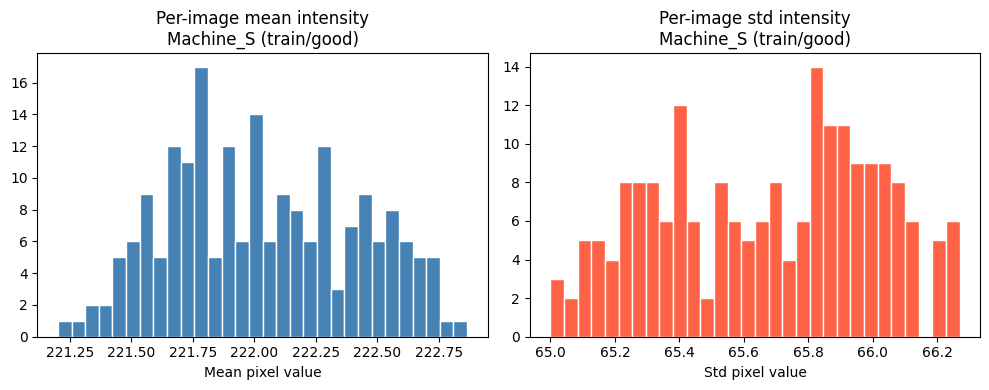


Folder: Machine_S - test/bad (200 images sampled)
  Pixel mean  : 224.4 ± 0.5
  Pixel std   : 62.3 ± 0.5
  Pixel range : [0, 255]


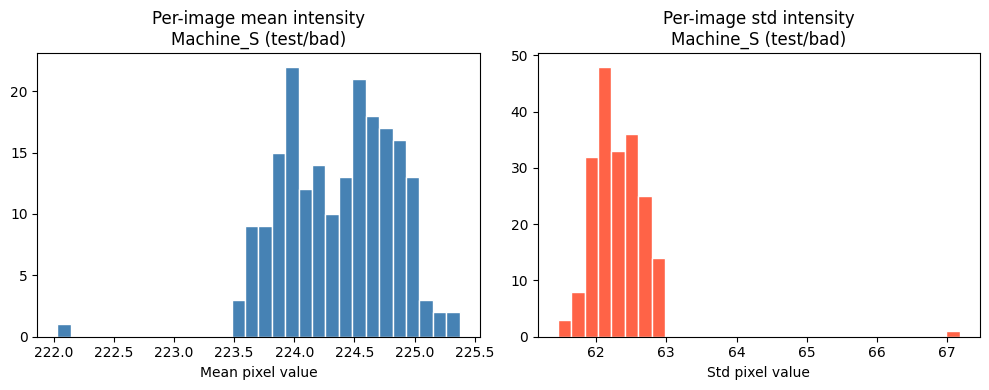


════════════════════════════════════════
 ANALYZING: Machine_DSV
════════════════════════════════════════

Folder: Machine_DSV - train/good (200 images sampled)
  Pixel mean  : 215.7 ± 0.4
  Pixel std   : 66.3 ± 0.3
  Pixel range : [0, 255]


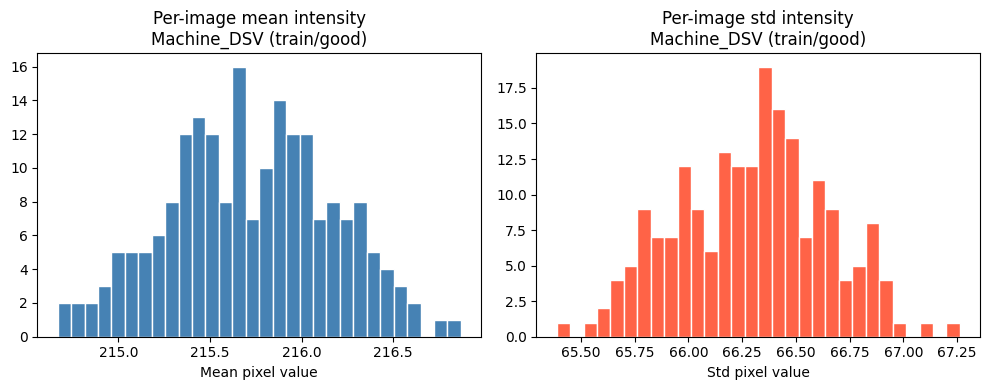


Folder: Machine_DSV - test/bad (200 images sampled)
  Pixel mean  : 217.1 ± 0.5
  Pixel std   : 59.8 ± 0.2
  Pixel range : [0, 255]


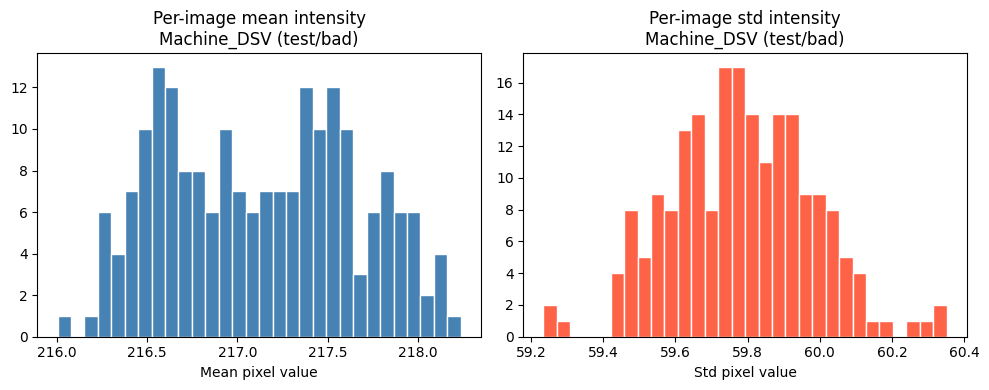

In [20]:
# scripts/pixel_stats.py

import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Unified set of allowed extensions based on your X-ray datasets
ALLOWED_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

def compute_pixel_stats(folder: str, dataset_name: str, split_name: str, max_images: int = 200):
    """Compute mean/std of pixel intensities across a folder of images."""
    folder_path = Path(folder)
    
    if not folder_path.exists():
        print(f"⚠️ Folder not found: {folder_path}")
        return None, None

    # Safely grab images matching our extensions
    paths = [p for p in folder_path.iterdir() if p.suffix.lower() in ALLOWED_EXTS]
    paths = paths[:max_images]  # Limit to max_images for speed

    if not paths:
        print(f"⚠️ No images found in: {folder_path}")
        return None, None

    means, stds, min_vals, max_vals = [], [], [], []

    for p in paths:
        # Convert to grayscale ("L") and float32 for accurate math
        arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())
        min_vals.append(arr.min())
        max_vals.append(arr.max())

    print(f"\nFolder: {dataset_name} - {split_name} ({len(paths)} images sampled)")
    print(f"  Pixel mean  : {np.mean(means):.1f} ± {np.std(means):.1f}")
    print(f"  Pixel std   : {np.mean(stds):.1f} ± {np.std(stds):.1f}")
    print(f"  Pixel range : [{np.min(min_vals):.0f}, {np.max(max_vals):.0f}]")

    # Plotting
    Path("results").mkdir(exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].hist(means, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_title(f"Per-image mean intensity\n{dataset_name} ({split_name})")
    axes[0].set_xlabel("Mean pixel value")
    
    axes[1].hist(stds, bins=30, color="tomato", edgecolor="white")
    axes[1].set_title(f"Per-image std intensity\n{dataset_name} ({split_name})")
    axes[1].set_xlabel("Std pixel value")
    
    plt.tight_layout()
    
    save_path = f"results/pixel_stats_{dataset_name}_{split_name.replace('/', '_')}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    return means, stds


# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    # Point these to your RESTRUCTURED anomalib_data folders!
    base_out_dir = Path(r"C:\Users\Inga\miniconda3\envs\capstone\capstone_xray\data\xray\anomalib_data")
    
    machine_s = base_out_dir / "Machine_S"
    machine_dsv = base_out_dir / "Machine_DSV"

    print("════════════════════════════════════════")
    print(" ANALYZING: Machine_S")
    print("════════════════════════════════════════")
    # Compare normal training jars vs defective test jars
    compute_pixel_stats(machine_s / "train/good", "Machine_S", "train/good")
    compute_pixel_stats(machine_s / "test/bad", "Machine_S", "test/bad")

    print("\n════════════════════════════════════════")
    print(" ANALYZING: Machine_DSV")
    print("════════════════════════════════════════")
    compute_pixel_stats(machine_dsv / "train/good", "Machine_DSV", "train/good")
    compute_pixel_stats(machine_dsv / "test/bad", "Machine_DSV", "test/bad")

On both machines, the test/bad images are only slightly brighter on average than the train/good images (224.4 vs 222.0 for Machine S; 217.1 vs 215.7 for Machine DSV).

Why this matters: If defective jars were massively darker or lighter, it would mean the X-ray was overexposing or underexposing based on the defect. Because the means and standard deviations are so close, it proves that the overall "structure" of the image remains intact when a defect is present.

Conclusion for PatchCore: The model cannot simply use a "global brightness" threshold to find defects. It is going to have to look deeply into the structural patterns of the glass to find the anomalies—which is exactly what PatchCore’s ResNet backbone is designed to do!

The Machine-to-Machine Drift
Notice how Machine_S (mean ~222) is universally brighter than Machine_DSV (mean ~215)?

What this means: Machine_S's X-ray tube is likely firing at a slightly higher voltage, or its detector is slightly more sensitive than Machine_DSV's.

Why your team was right: This ~7-point brightness drift is exactly why your team originally warned against mixing the datasets (Task 1). If you trained a single model on both machines without adjusting for this, the model might accidentally learn that "darker images are from Machine DSV" instead of focusing purely on the glass defects.

The fix for the future: If you ever do combine them, you will just add a 1-line normalization step to your PyTorch pipeline to make their brightness perfectly identical.